# Imports

In [1]:
import re
import json
import copy
import math
import unicodedata
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from copy import deepcopy
from tqdm.notebook import tqdm
 
import nltk
nltk.download('punkt',      quiet=True)
nltk.download('punkt_tab',  quiet=True)
nltk.download('stopwords',  quiet=True)
from nltk.tokenize import word_tokenize
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

### Seeding and setting device

In [2]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = "cpu"
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    device = "cuda"

print("Device:", device)

Device: cuda


## Q1 — Should Stopwords be Removed for the Translation Task?

In a text-classification task like TREC, stopwords (articles, prepositions, conjunctions) carry little discriminative signal and their removal reduces noise. Translation is fundamentally different: the goal is to reproduce the full meaning and grammatical structure of the source in the target language. Every word—including stopwords—is a load-bearing part of that structure.
So, no stopwords should not be removed for translation task.

# Load Dataset

In [3]:
def load_jsonl(path):
    """Load a JSONL file; return list of (de, en) string pairs."""
    pairs = []
    with open(path, encoding='utf-8') as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            # Normalize unicode strings like \u00e4 from the dataset
            de = unicodedata.normalize('NFC', obj['de'])
            en = unicodedata.normalize('NFC', obj['en'])
            pairs.append((de, en))
    return pairs
 
train_pairs = load_jsonl("data/train.jsonl")
val_pairs   = load_jsonl("data/val.jsonl")
test_pairs  = load_jsonl("data/test.jsonl")
 
print(f"Train: {len(train_pairs)}   Val: {len(val_pairs)}   Test: {len(test_pairs)}")
print("\nSample pair:")
print(f"  DE : {train_pairs[0][0]}")
print(f"  EN : {train_pairs[0][1]}")

Train: 29000   Val: 1014   Test: 1000

Sample pair:
  DE : Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.
  EN : Two young, White males are outside near many bushes.


## Preprocessing

In [4]:
PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3
SPECIAL_TOKENS = ['<pad>', '<sos>', '<eos>', '<unk>']
 
MAX_LEN = 50   # maximum sequence length
 
 
def text_preprocess_pipeline(text_list, lang='en', max_len=MAX_LEN):
    """Tokenise sentences, prepend <sos>, append <eos>, and pad to max_len.
 
    Args:
        text_list : list of raw sentence strings.
        lang      : 'de' or 'en'  — selects the NLTK tokeniser language.
        max_len   : fixed output sequence length.
 
    Returns:
        list of token lists, each of length max_len.
    """
    nltk_lang = 'german' if lang == 'de' else 'english'
    processed = []
    for text in tqdm(text_list, desc=f"Pre-processing ({lang.upper()})", leave=True):
        text   = text.lower().strip()
        tokens = word_tokenize(text, language=nltk_lang)
        # Truncate (reserve 2 slots for <sos> + <eos>)
        tokens = tokens[:max_len - 2]
        tokens = ['<sos>'] + tokens + ['<eos>']
        # Pad to max_len
        tokens += ['<pad>'] * (max_len - len(tokens))
        processed.append(tokens)
    return processed
 
 
def convert_text_to_idx(text_list_tokenized, create_vocab=True, token_to_idx=None):
    """Build a vocabulary and map tokens to integer indices.
 
    Args:
        text_list_tokenized : list of token lists.
        create_vocab        : if True, build a new vocab from the data.
        token_to_idx        : existing vocab dict (required when create_vocab=False).
 
    Returns (create_vocab=True):
        (converted_ids, token_to_idx, idx_to_token, token_freq)
    Returns (create_vocab=False):
        (converted_ids, token_freq)
    """
    if create_vocab:
        token_to_idx = {tok: i for i, tok in enumerate(SPECIAL_TOKENS)}
        idx_to_token = {i: tok for i, tok in enumerate(SPECIAL_TOKENS)}
        idx_counter  = len(SPECIAL_TOKENS)
    else:
        idx_to_token = {v: k for k, v in token_to_idx.items()}
 
    token_freq          = Counter()
    text_list_converted = []
 
    for tokens in tqdm(text_list_tokenized, desc="Building vocab / converting", leave=True):
        ids = []
        for tok in tokens:
            if tok not in token_to_idx:
                if create_vocab:
                    token_to_idx[tok]      = idx_counter
                    idx_to_token[idx_counter] = tok
                    idx_counter += 1
                else:
                    tok = '<unk>'
            token_freq[tok] += 1
            ids.append(token_to_idx[tok])
        text_list_converted.append(ids)
 
    if create_vocab:
        return text_list_converted, token_to_idx, idx_to_token, token_freq
    else:
        return text_list_converted, token_freq

In [5]:
# German
de_train_texts = [p[0] for p in train_pairs]
de_val_texts   = [p[0] for p in val_pairs]
de_test_texts  = [p[0] for p in test_pairs]
 
de_train_tok = text_preprocess_pipeline(de_train_texts, lang='de')
de_val_tok   = text_preprocess_pipeline(de_val_texts,   lang='de')
de_test_tok  = text_preprocess_pipeline(de_test_texts,  lang='de')
 
de_train_ids, de_tok2idx, de_idx2tok, de_freq_train = convert_text_to_idx(de_train_tok,  create_vocab=True)
de_val_ids, _ = convert_text_to_idx(de_val_tok,   create_vocab=False, token_to_idx=de_tok2idx)
de_test_ids, _ = convert_text_to_idx(de_test_tok,  create_vocab=False, token_to_idx=de_tok2idx)
 
# English
en_train_texts = [p[1] for p in train_pairs]
en_val_texts   = [p[1] for p in val_pairs]
en_test_texts  = [p[1] for p in test_pairs]
 
en_train_tok = text_preprocess_pipeline(en_train_texts, lang='en')
en_val_tok   = text_preprocess_pipeline(en_val_texts,   lang='en')
en_test_tok  = text_preprocess_pipeline(en_test_texts,  lang='en')
 
en_train_ids, en_tok2idx, en_idx2tok, en_freq_train = convert_text_to_idx(en_train_tok,  create_vocab=True)
en_val_ids, _ = convert_text_to_idx(en_val_tok,   create_vocab=False, token_to_idx=en_tok2idx)
en_test_ids, _ = convert_text_to_idx(en_test_tok,  create_vocab=False, token_to_idx=en_tok2idx)

# Show counts
SRC_VOCAB = len(de_tok2idx)
TGT_VOCAB = len(en_tok2idx)

print(f"\nGerman  vocabulary size : {SRC_VOCAB}")
print(f"English vocabulary size : {TGT_VOCAB}")

Pre-processing (DE):   0%|          | 0/29000 [00:00<?, ?it/s]

Pre-processing (DE):   0%|          | 0/1014 [00:00<?, ?it/s]

Pre-processing (DE):   0%|          | 0/1000 [00:00<?, ?it/s]

Building vocab / converting:   0%|          | 0/29000 [00:00<?, ?it/s]

Building vocab / converting:   0%|          | 0/1014 [00:00<?, ?it/s]

...

Pre-processing (EN):   0%|          | 0/1000 [00:00<?, ?it/s]

Building vocab / converting:   0%|          | 0/29000 [00:00<?, ?it/s]

Building vocab / converting:   0%|          | 0/1014 [00:00<?, ?it/s]

Building vocab / converting:   0%|          | 0/1000 [00:00<?, ?it/s]


German  vocabulary size : 18679
English vocabulary size : 10218


## Dataloader

In [6]:
BATCH_SIZE = 128
 
class TranslationDataset(Dataset):
    def __init__(self, src_ids, tgt_ids):
        self.src = torch.tensor(src_ids, dtype=torch.long)
        self.tgt = torch.tensor(tgt_ids, dtype=torch.long)
 
    def __len__(self):
        return len(self.src)
 
    def __getitem__(self, idx):
        return self.src[idx], self.tgt[idx]
 
 
train_loader = DataLoader(TranslationDataset(de_train_ids, en_train_ids), batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
val_loader = DataLoader(TranslationDataset(de_val_ids,   en_val_ids), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = DataLoader(TranslationDataset(de_test_ids,  en_test_ids), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
 
print(f"Batches — Train: {len(train_loader)}   Val: {len(val_loader)}   Test: {len(test_loader)}")

Batches — Train: 227   Val: 8   Test: 8


# Model (Scratch)

In [7]:
# Hyperparameters
D_MODEL        = 256
NUM_HEADS      = 8
NUM_ENC_LAYERS = 3
NUM_DEC_LAYERS = 3
D_FF           = 512
DROPOUT        = 0.1

In [8]:
class EmbeddingLayer(nn.Module):
    def __init__(self, d_model, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.d_model   = d_model
 
    def forward(self, x):
        return self.embedding(x) * math.sqrt(self.d_model)

class PositionalEncodingLayer(nn.Module):
    def __init__(self, d_model, max_len, dropout):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float()
                             * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))   # (1, max_len, d_model)
 
    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class MultiHeadAttention(nn.Module):
    """Custom multi-head scaled dot-product attention."""
    def __init__(self, d_model, num_heads, dropout=0.0):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model   = d_model
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
 
    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask, float('-inf'))
        probs = torch.softmax(scores, dim=-1)
        probs = self.dropout(probs)
        return torch.matmul(probs, V), probs
 
    def split_heads(self, x):
        B, L, _ = x.size()
        return x.view(B, L, self.num_heads, self.d_k).transpose(1, 2)
 
    def combine_heads(self, x):
        B, _, L, _ = x.size()
        return x.transpose(1, 2).contiguous().view(B, L, self.d_model)
 
    def forward(self, Q, K, V, mask=None):
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))
        out, _ = self.scaled_dot_product_attention(Q, K, V, mask)
        return self.W_o(self.combine_heads(out))
    
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.0):
        super().__init__()
        self.fc1     = nn.Linear(d_model, d_ff)
        self.fc2     = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
 
    def forward(self, x):
        return self.fc2(self.dropout(F.relu(self.fc1(x))))

In [9]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.self_attn    = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff, dropout)
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
 
    def forward(self, x, src_mask=None):
        attn_out = self.self_attn(x, x, x, src_mask)
        x = self.norm1(x + self.dropout(attn_out))
        x = self.norm2(x + self.dropout(self.feed_forward(x)))
        return x
    
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.self_attn    = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn   = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff, dropout)
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.norm3   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
 
    def forward(self, x, enc_out, tgt_mask=None, src_mask=None):
        # Masked self-attention
        self_out = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(self_out))
        # Cross-attention
        cross_out = self.cross_attn(x, enc_out, enc_out, src_mask)
        x = self.norm2(x + self.dropout(cross_out))
        # Position-wise FFN
        x = self.norm3(x + self.dropout(self.feed_forward(x)))
        return x

In [10]:
class Seq2SeqTransformer(nn.Module):
 
    def __init__(self, src_vocab_size, tgt_vocab_size,
                 d_model, num_heads, num_enc_layers, num_dec_layers,
                 d_ff, max_len, dropout):
        super().__init__()
        self.src_embedding = EmbeddingLayer(d_model, src_vocab_size)
        self.tgt_embedding = EmbeddingLayer(d_model, tgt_vocab_size)
        self.src_pos_enc   = PositionalEncodingLayer(d_model, max_len, dropout)
        self.tgt_pos_enc   = PositionalEncodingLayer(d_model, max_len, dropout)
 
        self.encoder_layers = nn.ModuleList(
            [EncoderLayer(d_model, num_heads, d_ff, dropout)
             for _ in range(num_enc_layers)])
        self.decoder_layers = nn.ModuleList(
            [DecoderLayer(d_model, num_heads, d_ff, dropout)
             for _ in range(num_dec_layers)])
 
        self.fc_out  = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)
 
    def _make_src_mask(self, src):
        return (src == PAD_IDX).unsqueeze(1).unsqueeze(2)
 
    def _make_tgt_mask(self, tgt):
        T = tgt.size(1)
        causal   = torch.triu(torch.ones(T, T, device=tgt.device), diagonal=1).bool()
        pad_mask = (tgt == PAD_IDX).unsqueeze(1).unsqueeze(2)
        return causal.unsqueeze(0).unsqueeze(0) | pad_mask
 
    def encode(self, src):
        src_mask = self._make_src_mask(src)
        x = self.src_pos_enc(self.src_embedding(src))
        for layer in self.encoder_layers:
            x = layer(x, src_mask)
        return x, src_mask
 
    def decode(self, tgt, enc_out, src_mask):
        tgt_mask = self._make_tgt_mask(tgt)
        x = self.tgt_pos_enc(self.tgt_embedding(tgt))
        for layer in self.decoder_layers:
            x = layer(x, enc_out, tgt_mask, src_mask)
        return self.fc_out(x)
 
    def forward(self, src, tgt):
        enc_out, src_mask = self.encode(src)
        return self.decode(tgt, enc_out, src_mask)
 
 
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [11]:
model1 = Seq2SeqTransformer(
    src_vocab_size=SRC_VOCAB, tgt_vocab_size=TGT_VOCAB,
    d_model=D_MODEL,  num_heads=NUM_HEADS,
    num_enc_layers=NUM_ENC_LAYERS, num_dec_layers=NUM_DEC_LAYERS,
    d_ff=D_FF, max_len=MAX_LEN, dropout=DROPOUT
).to(device)
 
print(f"\nModel 1 (Scratch) — Trainable params: {count_parameters(model1)/1e6:.3f}M")


Model 1 (Scratch) — Trainable params: 13.977M


### Training and Inference methods

In [12]:
def train_seq2seq(model, train_loader, val_loader, n_epochs, label="Model", lr=5e-4):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.98), eps=1e-9)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
 
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_weights  = None
 
    epoch_bar = tqdm(range(1, n_epochs + 1), desc=f"[{label}] Epochs", leave=True)
    for epoch in epoch_bar:
 
        # Train
        model.train()
        epoch_loss = 0.0
        batch_bar  = tqdm(train_loader, desc=f"  E{epoch:02d} train", leave=False)
        for src, tgt in batch_bar:
            src     = src.to(device)
            tgt     = tgt.to(device)
            tgt_in  = tgt[:, :-1]         # decoder input  (strip last token)
            tgt_out = tgt[:, 1:]          # expected output (strip <sos>)
 
            optimizer.zero_grad()
            logits = model(src, tgt_in)
            loss   = criterion(logits.reshape(-1, logits.size(-1)),
                               tgt_out.reshape(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
            batch_bar.set_postfix(loss=f"{loss.item():.4f}")
 
        train_losses.append(epoch_loss / len(train_loader))
 
        # Validate
        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            vbar = tqdm(val_loader, desc=f"  E{epoch:02d} val  ", leave=False)
            for src, tgt in vbar:
                src, tgt   = src.to(device), tgt.to(device)
                tgt_in, tgt_out = tgt[:, :-1], tgt[:, 1:]
                logits = model(src, tgt_in)
                loss   = criterion(logits.reshape(-1, logits.size(-1)),
                                   tgt_out.reshape(-1))
                v_loss += loss.item()
        val_losses.append(v_loss / len(val_loader))
        scheduler.step(val_losses[-1])
 
        if val_losses[-1] < best_val_loss:
            best_val_loss = val_losses[-1]
            best_weights  = copy.deepcopy(model.state_dict())
 
        epoch_bar.set_description(f"[{label}] Epoch {epoch:02d}/{n_epochs}")
        epoch_bar.set_postfix(train=f"{train_losses[-1]:.4f}", val=f"{val_losses[-1]:.4f}")
 
    model.load_state_dict(best_weights)
    return train_losses, val_losses

@torch.no_grad()
def greedy_decode(model, src_tensor, max_len=MAX_LEN):
    model.eval()
    src = src_tensor.unsqueeze(0).to(device)        # (1, src_len)
    enc_out, src_mask = model.encode(src)
 
    tgt_ids = [SOS_IDX]
    for _ in range(max_len - 1):
        tgt = torch.tensor([tgt_ids], dtype=torch.long, device=device)
        logits   = model.decode(tgt, enc_out, src_mask)  # (1, t, tgt_vocab)
        next_tok = logits[:, -1, :].argmax(dim=-1).item()
        tgt_ids.append(next_tok)
        if next_tok == EOS_IDX:
            break
    return tgt_ids
 
 
def ids_to_tokens(id_list, idx2tok):
    specials = {PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX}
    return [idx2tok[i] for i in id_list if i not in specials and i in idx2tok]

def plot_losses(train_losses, val_losses, title):
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, marker='o', markersize=3, label='Train')
    plt.plot(val_losses,   marker='s', markersize=3, label='Val')
    plt.title(f"{title} — Loss")
    plt.xlabel("Epoch"); plt.ylabel("Cross-Entropy Loss")
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

# Train (Scratch)

[Model1-Custom] Epochs:   0%|          | 0/60 [00:00<?, ?it/s]

  E01 train:   0%|          | 0/227 [00:00<?, ?it/s]

  E01 val  :   0%|          | 0/8 [00:00<?, ?it/s]

  E02 train:   0%|          | 0/227 [00:00<?, ?it/s]

  E02 val  :   0%|          | 0/8 [00:00<?, ?it/s]

...

  E58 val  :   0%|          | 0/8 [00:00<?, ?it/s]

  E59 train:   0%|          | 0/227 [00:00<?, ?it/s]

  E59 val  :   0%|          | 0/8 [00:00<?, ?it/s]

  E60 train:   0%|          | 0/227 [00:00<?, ?it/s]

  E60 val  :   0%|          | 0/8 [00:00<?, ?it/s]

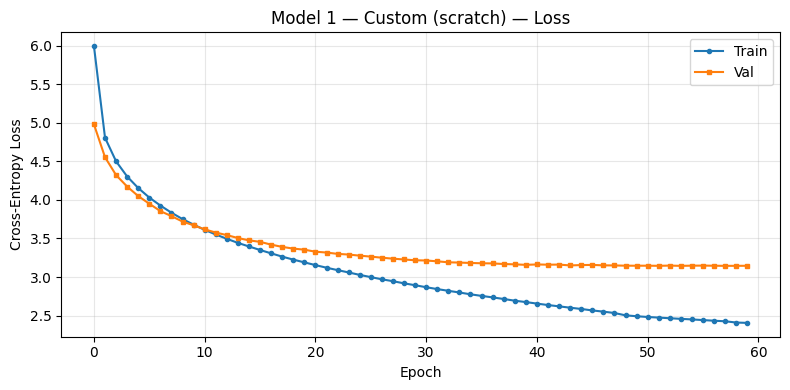

In [13]:
N_EPOCHS = 60
 
trl1, vll1 = train_seq2seq(model1, train_loader, val_loader, N_EPOCHS, label="Model1-Custom", lr=1e-4)
plot_losses(trl1, vll1, "Model 1 — Custom (scratch)")

# Encoder/Decoder layer -> nn.MultHeadAttention

In [14]:
class EncoderLayer_nnMHA(nn.Module):
 
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.self_attn    = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff, dropout)
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
 
    def forward(self, x, src_mask=None):
        kpm = src_mask.squeeze(1).squeeze(1) if src_mask is not None else None
        attn_out, _ = self.self_attn(x, x, x, key_padding_mask=kpm)
        x = self.norm1(x + self.dropout(attn_out))
        x = self.norm2(x + self.dropout(self.feed_forward(x)))
        return x
 
 
# Decoder layer with nn.MultiheadAttention
class DecoderLayer_nnMHA(nn.Module):
 
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.self_attn    = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.cross_attn   = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff, dropout)
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.norm3   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
 
    def forward(self, x, enc_out,
                tgt_causal_mask=None,
                tgt_key_padding_mask=None,
                src_key_padding_mask=None):
        # Masked self-attention
        sa_out, _ = self.self_attn(
            x, x, x,
            attn_mask=tgt_causal_mask,
            key_padding_mask=tgt_key_padding_mask)
        x = self.norm1(x + self.dropout(sa_out))
        # Cross-attention
        ca_out, _ = self.cross_attn(
            x, enc_out, enc_out,
            key_padding_mask=src_key_padding_mask)
        x = self.norm2(x + self.dropout(ca_out))
        # FFN
        x = self.norm3(x + self.dropout(self.feed_forward(x)))
        return x

In [15]:
class Seq2SeqTransformer_nnMHA(nn.Module):
    """Same architecture as Model 1, but custom MHA replaced with nn.MHA."""
 
    def __init__(self, src_vocab_size, tgt_vocab_size,
                 d_model, num_heads, num_enc_layers, num_dec_layers,
                 d_ff, max_len, dropout):
        super().__init__()
        self.src_embedding = EmbeddingLayer(d_model, src_vocab_size)
        self.tgt_embedding = EmbeddingLayer(d_model, tgt_vocab_size)
        self.src_pos_enc   = PositionalEncodingLayer(d_model, max_len, dropout)
        self.tgt_pos_enc   = PositionalEncodingLayer(d_model, max_len, dropout)
 
        self.encoder_layers = nn.ModuleList(
            [EncoderLayer_nnMHA(d_model, num_heads, d_ff, dropout)
             for _ in range(num_enc_layers)])
        self.decoder_layers = nn.ModuleList(
            [DecoderLayer_nnMHA(d_model, num_heads, d_ff, dropout)
             for _ in range(num_dec_layers)])
 
        self.fc_out  = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)
 
    def _make_src_mask(self, src):
        return (src == PAD_IDX).unsqueeze(1).unsqueeze(2)
 
    def encode(self, src):
        src_mask = self._make_src_mask(src)
        x = self.src_pos_enc(self.src_embedding(src))
        for layer in self.encoder_layers:
            x = layer(x, src_mask)
        return x, src_mask
 
    def decode(self, tgt, enc_out, src_mask):
        T = tgt.size(1)
        tgt_causal = torch.triu(
            torch.full((T, T), float('-inf'), device=tgt.device), diagonal=1)
        tgt_kpm = (tgt == PAD_IDX)
        src_kpm = src_mask.squeeze(1).squeeze(1)
 
        x = self.tgt_pos_enc(self.tgt_embedding(tgt))
        for layer in self.decoder_layers:
            x = layer(x, enc_out,
                      tgt_causal_mask=tgt_causal,
                      tgt_key_padding_mask=tgt_kpm,
                      src_key_padding_mask=src_kpm)
        return self.fc_out(x)
 
    def forward(self, src, tgt):
        enc_out, src_mask = self.encode(src)
        return self.decode(tgt, enc_out, src_mask)

In [16]:
model2 = Seq2SeqTransformer_nnMHA(
    src_vocab_size=SRC_VOCAB, tgt_vocab_size=TGT_VOCAB,
    d_model=D_MODEL,  num_heads=NUM_HEADS,
    num_enc_layers=NUM_ENC_LAYERS, num_dec_layers=NUM_DEC_LAYERS,
    d_ff=D_FF, max_len=MAX_LEN, dropout=DROPOUT
).to(device)
 
print(f"Model 2 (nn.MultiheadAttention) — Trainable params: {count_parameters(model2)/1e6:.3f}M")

Model 2 (nn.MultiheadAttention) — Trainable params: 13.977M


# Train (nn.MHA)

[Model2-nn.MHA] Epochs:   0%|          | 0/60 [00:00<?, ?it/s]

  E01 train:   0%|          | 0/227 [00:00<?, ?it/s]

f:\PhD Stuff\DL Lab\.venv\Lib\site-packages\torch\nn\modules\activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


  E01 val  :   0%|          | 0/8 [00:00<?, ?it/s]

  E02 train:   0%|          | 0/227 [00:00<?, ?it/s]

...

  E58 val  :   0%|          | 0/8 [00:00<?, ?it/s]

  E59 train:   0%|          | 0/227 [00:00<?, ?it/s]

  E59 val  :   0%|          | 0/8 [00:00<?, ?it/s]

  E60 train:   0%|          | 0/227 [00:00<?, ?it/s]

  E60 val  :   0%|          | 0/8 [00:00<?, ?it/s]

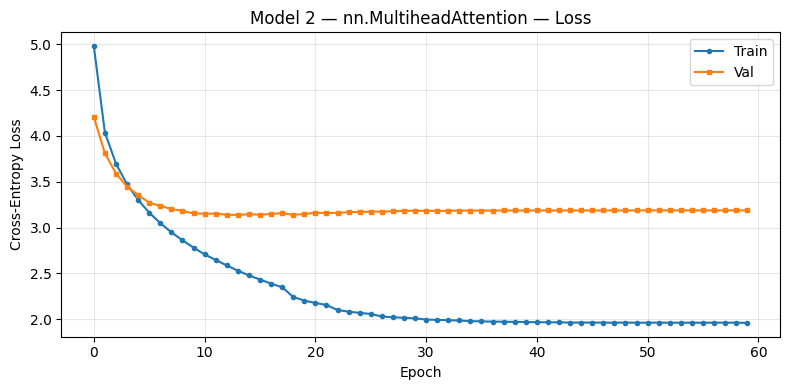

In [17]:
trl2, vll2 = train_seq2seq(model2, train_loader, val_loader, N_EPOCHS, label="Model2-nn.MHA", lr=5e-4)
plot_losses(trl2, vll2, "Model 2 — nn.MultiheadAttention")

# torch.nn.Transformer backbone

In [18]:
class Seq2SeqTransformer_nn(nn.Module):
    """Seq2Seq model using torch.nn.Transformer as the backbone."""
 
    def __init__(self, src_vocab_size, tgt_vocab_size,
                 d_model, num_heads, num_enc_layers, num_dec_layers,
                 d_ff, max_len, dropout):
        super().__init__()
        self.src_embedding = EmbeddingLayer(d_model, src_vocab_size)
        self.tgt_embedding = EmbeddingLayer(d_model, tgt_vocab_size)
        self.src_pos_enc   = PositionalEncodingLayer(d_model, max_len, dropout)
        self.tgt_pos_enc   = PositionalEncodingLayer(d_model, max_len, dropout)
 
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=num_heads,
            num_encoder_layers=num_enc_layers,
            num_decoder_layers=num_dec_layers,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True
        )
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)
 
    def encode(self, src):
        src_kpm = (src == PAD_IDX)
        src_emb = self.src_pos_enc(self.src_embedding(src))
        memory  = self.transformer.encoder(
            src_emb, src_key_padding_mask=src_kpm)
        return memory, src_kpm
 
    def decode(self, tgt, memory, src_kpm):
        T    = tgt.size(1)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(
            T, device=tgt.device).bool()
        tgt_kpm  = (tgt == PAD_IDX)
        tgt_emb  = self.tgt_pos_enc(self.tgt_embedding(tgt))
        out      = self.transformer.decoder(
            tgt_emb, memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_kpm,
            memory_key_padding_mask=src_kpm)
        return self.fc_out(out)
 
    def forward(self, src, tgt):
        memory, src_kpm = self.encode(src)
        return self.decode(tgt, memory, src_kpm)

In [19]:
model3 = Seq2SeqTransformer_nn(
    src_vocab_size=SRC_VOCAB, tgt_vocab_size=TGT_VOCAB,
    d_model=D_MODEL,  num_heads=NUM_HEADS,
    num_enc_layers=NUM_ENC_LAYERS, num_dec_layers=NUM_DEC_LAYERS,
    d_ff=D_FF, max_len=MAX_LEN, dropout=DROPOUT
).to(device)
 
print(f"Model 3 (nn.Transformer) — Trainable params: {count_parameters(model3)/1e6:.3f}M")

Model 3 (nn.Transformer) — Trainable params: 13.978M


# Train (nn.transformer)

[Model3-nn.Transformer] Epochs:   0%|          | 0/60 [00:00<?, ?it/s]

  E01 train:   0%|          | 0/227 [00:00<?, ?it/s]

  E01 val  :   0%|          | 0/8 [00:00<?, ?it/s]

f:\PhD Stuff\DL Lab\.venv\Lib\site-packages\torch\nn\modules\transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


  E02 train:   0%|          | 0/227 [00:00<?, ?it/s]

...

  E58 val  :   0%|          | 0/8 [00:00<?, ?it/s]

  E59 train:   0%|          | 0/227 [00:00<?, ?it/s]

  E59 val  :   0%|          | 0/8 [00:00<?, ?it/s]

  E60 train:   0%|          | 0/227 [00:00<?, ?it/s]

  E60 val  :   0%|          | 0/8 [00:00<?, ?it/s]

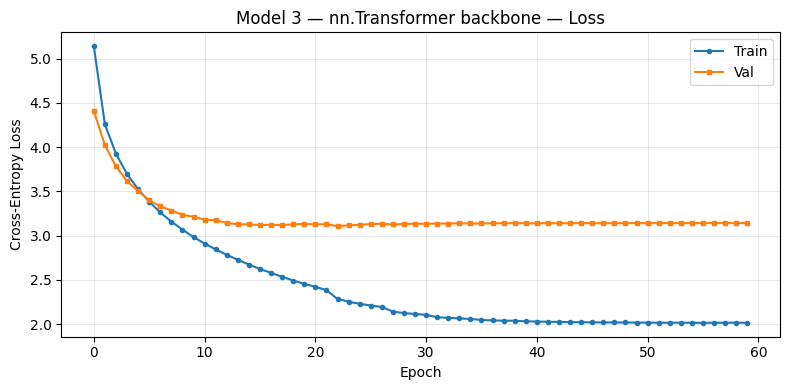

In [20]:
trl3, vll3 = train_seq2seq(model3, train_loader, val_loader, N_EPOCHS, label="Model3-nn.Transformer", lr=5e-4)
plot_losses(trl3, vll3, "Model 3 — nn.Transformer backbone")

# Evaluation

In [21]:
def compute_corpus_bleu(model, test_src_ids, test_en_tok):
    
    model.eval()
    hypotheses  = []
    references  = []
    smoother    = SmoothingFunction().method1
 
    bar = tqdm(test_src_ids, desc=f"  Translating", leave=False)
    with torch.no_grad():
        for src_ids in bar:
            src_tensor = torch.tensor(src_ids, dtype=torch.long)
            pred_ids   = greedy_decode(model, src_tensor, max_len=MAX_LEN)
            hyp        = ids_to_tokens(pred_ids, en_idx2tok)
            hypotheses.append(hyp)

    specials = {'<pad>', '<sos>', '<eos>', '<unk>'}
    for tok_seq in test_en_tok:
        ref = [t for t in tok_seq if t not in specials]
        references.append([ref])
 
    bleu = corpus_bleu(references, hypotheses, smoothing_function=smoother)
    return bleu, hypotheses

In [22]:
print("Computing BLEU scores …")
 
bleu1, hyps1 = compute_corpus_bleu(model1, de_test_ids, en_test_tok)
print(f"  Model 1 (Custom)         BLEU = {bleu1:.4f}")
 
bleu2, hyps2 = compute_corpus_bleu(model2, de_test_ids, en_test_tok)
print(f"  Model 2 (nn.MHA)         BLEU = {bleu2:.4f}")
 
bleu3, hyps3 = compute_corpus_bleu(model3, de_test_ids, en_test_tok)
print(f"  Model 3 (nn.Transformer) BLEU = {bleu3:.4f}")

Computing BLEU scores …


  Translating:   0%|          | 0/1000 [00:00<?, ?it/s]

  Model 1 (Custom)         BLEU = 0.2936


  Translating:   0%|          | 0/1000 [00:00<?, ?it/s]

  Model 2 (nn.MHA)         BLEU = 0.2830


  Translating:   0%|          | 0/1000 [00:00<?, ?it/s]

  Model 3 (nn.Transformer) BLEU = 0.3075


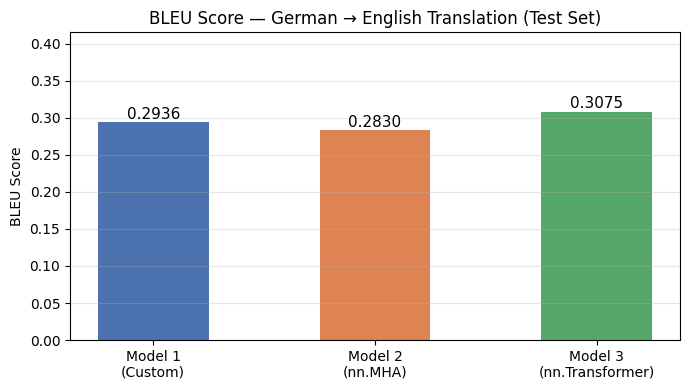

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))
model_labels = ["Model 1\n(Custom)", "Model 2\n(nn.MHA)", "Model 3\n(nn.Transformer)"]
bleu_scores  = [bleu1, bleu2, bleu3]
bar_colors   = ["#4C72B0", "#DD8452", "#55A868"]
bars = ax.bar(model_labels, bleu_scores, color=bar_colors, width=0.5)
for bar, s in zip(bars, bleu_scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f"{s:.4f}", ha='center', va='bottom', fontsize=11)
ax.set_title("BLEU Score — German → English Translation (Test Set)")
ax.set_ylabel("BLEU Score")
ax.set_ylim(0, max(bleu_scores) * 1.35)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# Sample translations
SAMPLE_INDICES = [0, 7, 14]
 
specials_set = {PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX}
sep = "=" * 80
 
print(f"\n{sep}")
print("Sample Translations — 3 test-set examples across all three models")
print(sep)
 
for idx in SAMPLE_INDICES:
    src_tok = ids_to_tokens(de_test_ids[idx], de_idx2tok)
    ref_tok = [t for t in en_test_tok[idx]
               if t not in {'<pad>', '<sos>', '<eos>', '<unk>'}]
 
    pred1 = ' '.join(hyps1[idx]) if hyps1[idx] else '<empty>'
    pred2 = ' '.join(hyps2[idx]) if hyps2[idx] else '<empty>'
    pred3 = ' '.join(hyps3[idx]) if hyps3[idx] else '<empty>'
 
    print(f"\n  Example {idx + 1}")
    print(f"    Source (DE)                : {' '.join(src_tok)}")
    print(f"    Reference (EN)             : {' '.join(ref_tok)}")
    print(f"    Model 1 (Custom)           : {pred1}")
    print(f"    Model 2 (nn.MHA)           : {pred2}")
    print(f"    Model 3 (nn.Transformer)   : {pred3}")
 
print(f"\n{sep}")


Sample Translations — 3 test-set examples across all three models

  Example 1
    Source (DE)                : ein mann mit einem orangefarbenen hut , der etwas .
    Reference (EN)             : a man in an orange hat starring at something .
    Model 1 (Custom)           : a man in an orange hat is about something with a black hat .
    Model 2 (nn.MHA)           : a man in an orange hat is pouring something .
    Model 3 (nn.Transformer)   : a man in an orange hat is looking at something .

  Example 8
    Source (DE)                : ein junge in einem roten trikot versucht , die home base zu erreichen , während der catcher im blauen trikot versucht , ihn zu fangen .
    Reference (EN)             : a boy in a red uniform is attempting to avoid getting out at home plate , while the catcher in the blue uniform is attempting to catch him .
    Model 1 (Custom)           : a boy in a red jersey tries to catch the base while the base runner tries to catch him in the base while the ba